In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np

INPUT_LENGTH = 24
OUTPUT_LENGTH = 24

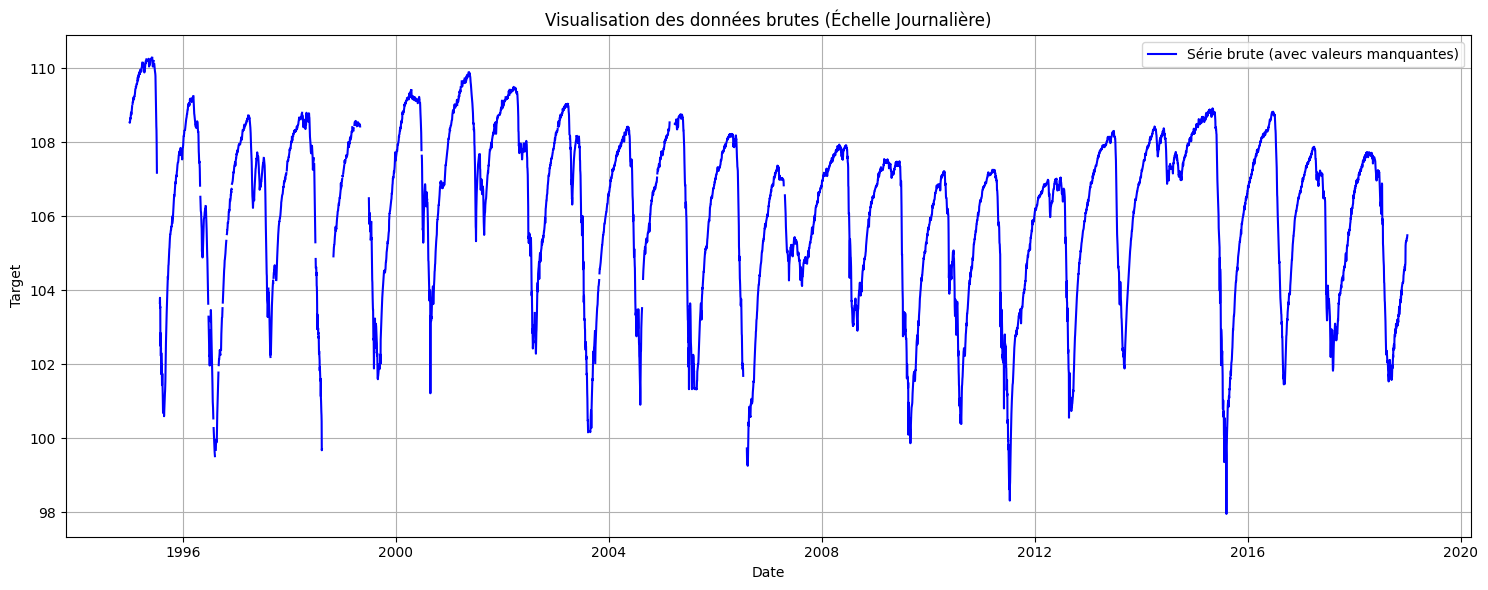

In [3]:
#1)
df_train_init = pd.read_csv(
	"train.csv", 
	sep=';', 
	parse_dates=['date'], 
	index_col='date'
)

df_test_init = pd.read_csv(
	"test.csv", 
	sep=';', 
	parse_dates=['date'], 
	index_col='date'
)

plt.figure(figsize=(15, 6))
plt.plot(df_train_init.index, df_train_init['target'], label='Série brute (avec valeurs manquantes)', color='blue')

plt.title('Visualisation des données brutes (Échelle Journalière)')
plt.xlabel('Date')
plt.ylabel('Target')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

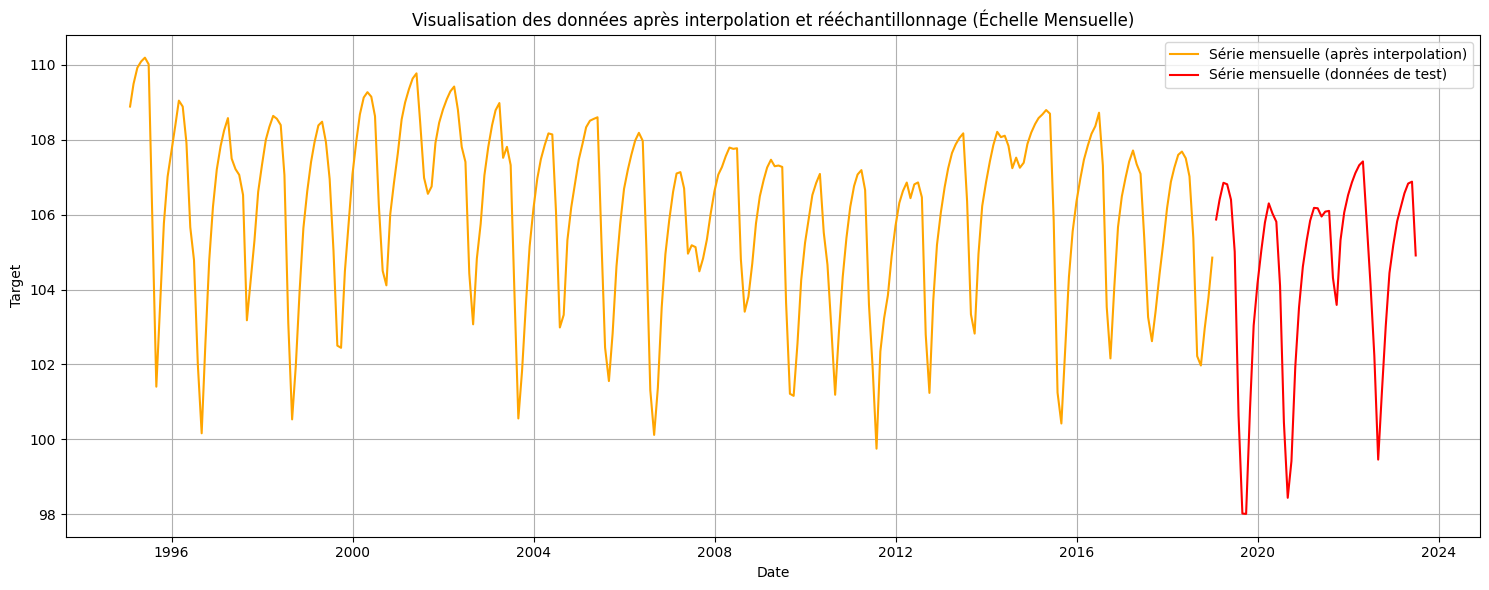

In [4]:
#2)
df_train_interpolated = df_train_init.interpolate(method='time')
df_train_monthly = df_train_interpolated.resample('ME').mean()

df_test_interpolated = df_test_init.interpolate(method='time')
df_test_monthly = df_test_interpolated.resample('ME').mean()

plt.figure(figsize=(15, 6))
plt.plot(df_train_monthly.index, df_train_monthly['target'], label='Série mensuelle (après interpolation)', color='orange')
plt.plot(df_test_monthly.index, df_test_monthly['target'], label='Série mensuelle (données de test)', color='red')
plt.title('Visualisation des données après interpolation et rééchantillonnage (Échelle Mensuelle)')
plt.xlabel('Date')
plt.ylabel('Target')
plt.grid(True)
plt.legend()
plt.tight_layout()

In [5]:
from sklearn.preprocessing import MinMaxScaler

def create_sequences(data, seq_length, target_col, output_lenght=1):
	xs = []
	ys = []
	for i in range(len(data) - seq_length - output_lenght + 1):
		x = data[target_col].iloc[i:(i + seq_length)].values
		y = data[target_col].iloc[(i + seq_length):(i + seq_length + output_lenght)].values
		xs.append(x)
		ys.append(y)
		
	return torch.tensor(np.array(xs), dtype=torch.float32), torch.tensor(np.array(ys), dtype=torch.float32)


nb_valid = 48 

df_train = df_train_monthly[:-nb_valid].copy()
df_valid = df_train_monthly[-nb_valid:].copy()
df_test = df_test_monthly.copy()

# ---- NORMALISATION ----
scaler = MinMaxScaler()

df_train['target'] = scaler.fit_transform(df_train[['target']])
df_valid['target'] = scaler.transform(df_valid[['target']])
df_test['target'] = scaler.transform(df_test[['target']])
# -----------------------

trainX, trainY = create_sequences(df_train, seq_length=INPUT_LENGTH, target_col='target', output_lenght=OUTPUT_LENGTH)
validX, validY = create_sequences(df_valid, seq_length=INPUT_LENGTH, target_col='target', output_lenght=OUTPUT_LENGTH)
testX, testY = create_sequences(df_test, seq_length=INPUT_LENGTH, target_col='target', output_lenght=OUTPUT_LENGTH)

In [6]:
class Model(nn.Module): 
	def __init__(self, output_dim, dense1_size, dense2_size):
		super(Model, self).__init__()

		self.lstm1 = nn.LSTM(input_size=1, hidden_size=12, batch_first=True)
		self.lstm2 = nn.LSTM(input_size=12, hidden_size=dense1_size, batch_first=True)
		self.dense1 = nn.Linear(dense1_size, dense2_size)
		self.dense2 = nn.Linear(dense2_size, output_dim)

	def forward(self, x):
		x = x.unsqueeze(-1)
		
		lstm1_out, _ = self.lstm1(x)
		lstm2_out, _ = self.lstm2(lstm1_out)
		
		out = self.dense1(lstm2_out[:, -1, :])
		out = torch.relu(out)
		out = self.dense2(out)
		
		return out

In [7]:
model = Model(output_dim=OUTPUT_LENGTH, dense1_size=32, dense2_size=16)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

#Epochs
num_epochs = 2000

for epoch in range(num_epochs):
	model.train()

	outputs = model(trainX)
		
	loss = criterion(outputs.squeeze(), trainY)
	optimizer.zero_grad()
	loss.backward()
	optimizer.step()
	optimizer.zero_grad()
   
	if (epoch+1) % 10 == 0:
		with torch.no_grad():
			model.eval()
			val_outputs = model(validX)
			val_loss = criterion(val_outputs.squeeze(), validY)
			print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Validation Loss: {val_loss.item():.4f}')
		print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
		
print('End!')	

c:\Users\kylia\OneDrive\Bureau\Cours\Apprentissage_IA\final lab\.venv\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([1, 24])) that is different to the input size (torch.Size([24])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [10/2000], Loss: 0.4094, Validation Loss: 0.3455
Epoch [10/2000], Loss: 0.4094
Epoch [20/2000], Loss: 0.3690, Validation Loss: 0.3096
Epoch [20/2000], Loss: 0.3690
Epoch [30/2000], Loss: 0.2973, Validation Loss: 0.2444
Epoch [30/2000], Loss: 0.2973
Epoch [40/2000], Loss: 0.1832, Validation Loss: 0.1677
Epoch [40/2000], Loss: 0.1832
Epoch [50/2000], Loss: 0.1273, Validation Loss: 0.1164
Epoch [50/2000], Loss: 0.1273
Epoch [60/2000], Loss: 0.0876, Validation Loss: 0.0686
Epoch [60/2000], Loss: 0.0876
Epoch [70/2000], Loss: 0.0646, Validation Loss: 0.0476
Epoch [70/2000], Loss: 0.0646
Epoch [80/2000], Loss: 0.0530, Validation Loss: 0.0397
Epoch [80/2000], Loss: 0.0530
Epoch [90/2000], Loss: 0.0482, Validation Loss: 0.0393
Epoch [90/2000], Loss: 0.0482
Epoch [100/2000], Loss: 0.0465, Validation Loss: 0.0380
Epoch [100/2000], Loss: 0.0465
Epoch [110/2000], Loss: 0.0459, Validation Loss: 0.0374
Epoch [110/2000], Loss: 0.0459
Epoch [120/2000], Loss: 0.0458, Validation Loss: 0.0373
Epoch

shape of the test data:  torch.Size([7, 24]) torch.Size([7, 24])


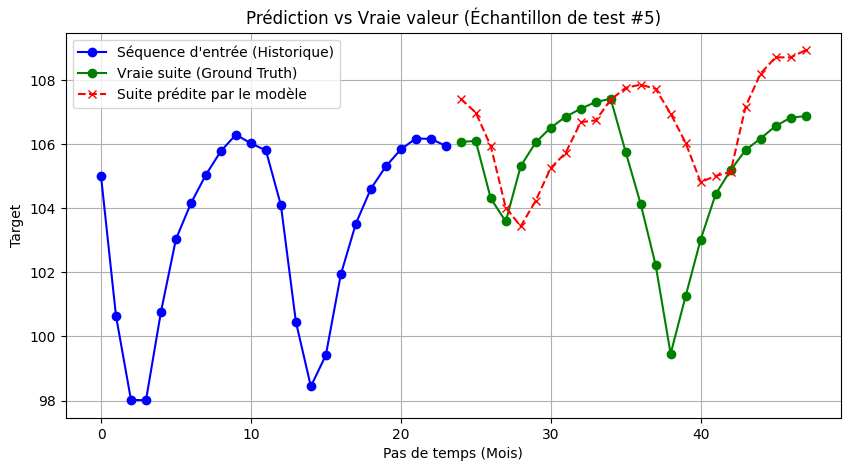

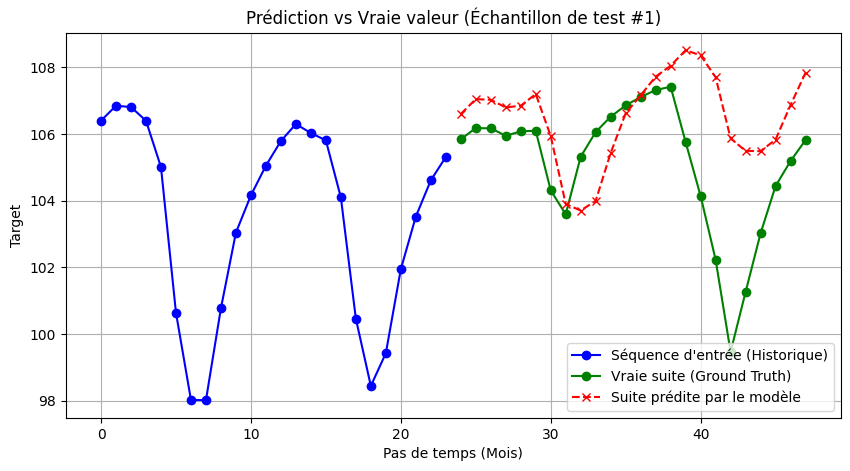

IndexError: index 9 is out of bounds for dimension 0 with size 7

In [8]:
def plot_prediction(model, testX, testY, scaler=None, sample_idx=0):
	model.eval()
	with torch.no_grad():
		predictions = model(testX)
	
	input_seq = testX[sample_idx].squeeze().numpy() 
	true_target = testY[sample_idx].squeeze().numpy()   
	pred_target = predictions[sample_idx].squeeze().numpy() 
	
	if scaler is not None:
		input_seq = scaler.inverse_transform(input_seq.reshape(-1, 1)).flatten()
		true_target = scaler.inverse_transform(true_target.reshape(-1, 1)).flatten()
		pred_target = scaler.inverse_transform(pred_target.reshape(-1, 1)).flatten()
	
	time_input = np.arange(len(input_seq))
	time_target = np.arange(len(input_seq), len(input_seq) + len(true_target))
	
	plt.figure(figsize=(10, 5))
	
	plt.plot(time_input, input_seq, label='Séquence d\'entrée (Historique)', color='blue', marker='o')
	
	plt.plot(time_target, true_target, label='Vraie suite (Ground Truth)', color='green', marker='o')
	
	plt.plot(time_target, pred_target, label='Suite prédite par le modèle', color='red', linestyle='--', marker='x')
	
	plt.title(f'Prédiction vs Vraie valeur (Échantillon de test #{sample_idx})')
	plt.xlabel('Pas de temps (Mois)')
	plt.ylabel('Target')
	plt.legend()
	plt.grid(True)
	plt.show()

print("shape of the test data: ", testX.shape, testY.shape)

plot_prediction(model, testX, testY, scaler=scaler, sample_idx=5)
plot_prediction(model, testX, testY, scaler=scaler, sample_idx=1)
plot_prediction(model, testX, testY, scaler=scaler, sample_idx=9)